# GKP-Based Quantum Error Correction in Photonic Systems
**Series:** GKP-QEC (S04)


## Multi-qubit logical systems

So far we have looked at single logical qubits. Now we move to entanglement, because that is where logical noise really shows its teeth.

We study two simple states: a Bell state (2 qubits) and a GHZ state (3 qubits). In both cases we apply the same logical noise to every qubit and then measure correlation observables.

These observables are near 1 in the ideal state, so their decay is a direct, software-level signal that entanglement is being washed out.

If you want to explore further, change the `ps` range or swap the noise channel in the code cells and rerun. You will see how basis choice and noise type change the decay.


In [1]:
import os

# Ensure a writable Matplotlib cache and a safe backend for notebooks
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib
try:
    from IPython import get_ipython

    if get_ipython() is not None:
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml


def apply_plot_style():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "axes.axisbelow": True,
            "grid.alpha": 0.25,
            "grid.linestyle": "--",
            "axes.labelsize": 12,
            "axes.titlesize": 13,
            "axes.titlepad": 10,
            "legend.frameon": False,
            "legend.fontsize": 10,
            "lines.linewidth": 2.2,
            "lines.markersize": 4.5,
        }
    )


apply_plot_style()


### Bell state correlations

For a Bell state, the correlations ⟨X⊗X⟩ and ⟨Z⊗Z⟩ are both strong. That is why we measure them: they are simple, high-contrast indicators that the two qubits are still entangled.

As noise increases, both correlations decay. The rate of decay is the logical signature of how quickly entanglement is lost under the chosen noise channel.


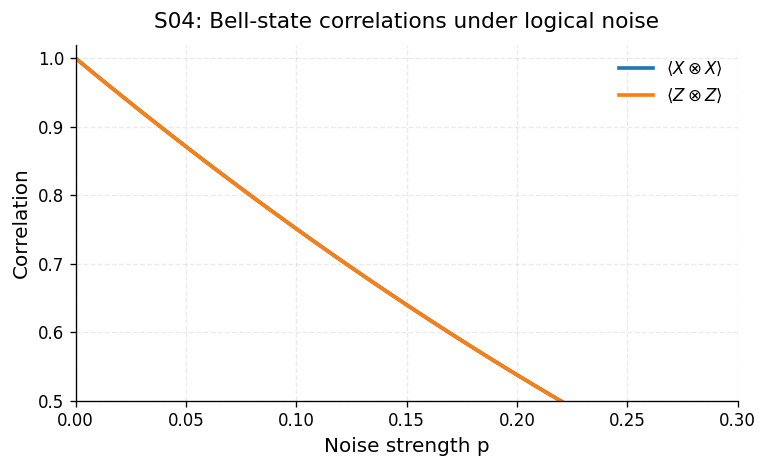

In [2]:
dev2 = qml.device("default.mixed", wires=2)


@qml.qnode(dev2)
def bell_correlations(p):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])

    qml.DepolarizingChannel(p, wires=0)
    qml.DepolarizingChannel(p, wires=1)

    xx = qml.expval(qml.PauliX(0) @ qml.PauliX(1))
    zz = qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))
    return xx, zz


ps = np.linspace(0.0, 0.30, 61)
xx_vals = []
zz_vals = []
for p in ps:
    xx, zz = bell_correlations(p)
    xx_vals.append(xx)
    zz_vals.append(zz)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(ps, xx_vals, label=r"$\langle X \otimes X \rangle$")
ax.plot(ps, zz_vals, label=r"$\langle Z \otimes Z \rangle$")
ax.set_xlabel("Noise strength p")
ax.set_ylabel("Correlation")
ax.set_title("S04: Bell-state correlations under logical noise")
ax.set_xlim(ps.min(), ps.max())
ax.set_ylim(0.5, 1.02)
ax.legend()
fig.tight_layout()
plt.show()


### How to read the Bell plot

Because we use depolarizing noise here, the decay is fairly symmetric and both curves fall together. If you swap the noise channel in the code cell to phase flip or bit flip, you will see the basis dependence show up as different decay rates between ⟨X⊗X⟩ and ⟨Z⊗Z⟩.

That is a useful reminder that "entanglement loss" can look different depending on how you probe it.


### GHZ state coherence

A GHZ state spreads its coherence across all three qubits, so it is even more fragile. We track ⟨X⊗X⊗X⟩ as a proxy for global coherence and ⟨Z0 Z1⟩ as a more local check.

As noise increases, the global term typically drops faster because it depends on every qubit staying coherent at once. This is why multi-qubit logical noise models matter so much for algorithm-level behavior.


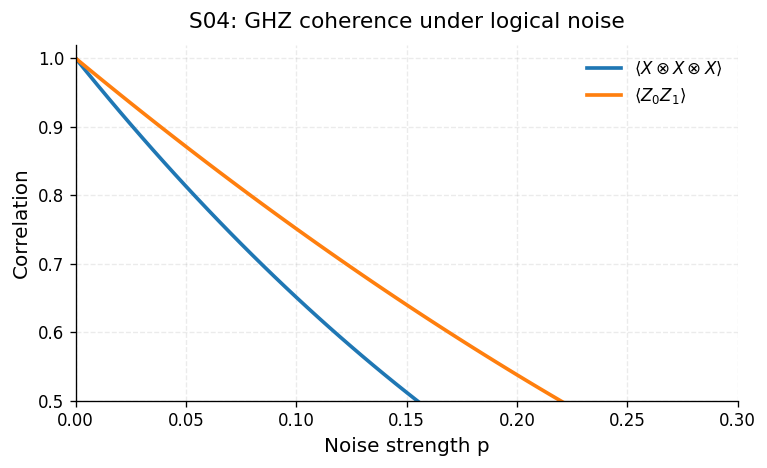

In [3]:
dev3 = qml.device("default.mixed", wires=3)


@qml.qnode(dev3)
def ghz_correlations(p):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[0, 2])

    for w in [0, 1, 2]:
        qml.DepolarizingChannel(p, wires=w)

    xxx = qml.expval(qml.PauliX(0) @ qml.PauliX(1) @ qml.PauliX(2))
    zz = qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))
    return xxx, zz


ps = np.linspace(0.0, 0.30, 61)
xxx_vals = []
zz_vals = []
for p in ps:
    xxx, zz = ghz_correlations(p)
    xxx_vals.append(xxx)
    zz_vals.append(zz)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(ps, xxx_vals, label=r"$\langle X \otimes X \otimes X \rangle$")
ax.plot(ps, zz_vals, label=r"$\langle Z_0 Z_1 \rangle$")
ax.set_xlabel("Noise strength p")
ax.set_ylabel("Correlation")
ax.set_title("S04: GHZ coherence under logical noise")
ax.set_xlim(ps.min(), ps.max())
ax.set_ylim(0.5, 1.02)
ax.legend()
fig.tight_layout()
plt.show()


### What to take away

Single-qubit noise already reduces coherence, but entangled states amplify that effect. A small amount of logical noise on each wire can erase the correlations that make Bell and GHZ states useful.

This is the software-level reason error correction is essential for multi-qubit algorithms. It is not just about keeping individual qubits clean. It is about preserving the correlations that algorithms depend on.
